## NASA'S Kepler Exoplanet Candidate Detection Using Machine Learning

## Introduction

 Kepler mission was a space telescope designed to search for planets outside our Solar System, known as exoplanets.

Kepler observed thousands of stars and continuously measured their brightness over time. These measurements form a **stellar light curve**, which represents how the brightness of a star changes during an observation period.

When a planet passes in front of its host star, it can block a very small amount of the star's light. This produces a small decrease in observed brightness called a **transit**.

These transit signals can be difficult to identify because stellar light curves may also contain noise, natural stellar variability, measurement errors, and other unusual patterns.

In this project, NASA Kepler stellar light-curve data is analyzed using Python, statistical feature engineering, machine learning techniques to identify unusual astronomical patterns and transit-like signals.

The project treats the task primarily as an **unsupervised anomaly-detection and signal-screening problem**. The objective is to identify observations that are unusual compared with normal stellar behavior and prioritize potentially interesting transit-like candidates for further analysis.

> **Important:** An anomaly or transit-like signal detected by this project is only a screening result and does not confirm the existence of an exoplanet. Scientific confirmation requires additional astronomical validation.

## Why is the project called Kepler?

The project is named "Kepler" because the dataset is based on stellar observations collected by  Kepler Space Telescope.

The spacecraft itself was named after Johannes Kepler (1571–1630), the German astronomer whose laws of planetary motion helped establish our understanding of how planets move around stars.

 Kepler mission was a space-based planet-hunting mission designed to search for planets orbiting stars outside our Solar System.

Therefore, "Kepler" in this project refers to the  mission and the astronomical observations produced by that mission.

##  Why is Kepler useful for this project?

Kepler is highly relevant to this project because the project focuses on detecting unusual patterns in astronomical time-series data.

The Kepler dataset contains stellar flux measurements collected over a sequence of observations.

This makes it possible to:

1. Analyze stellar brightness variations.

2. Identify unusual changes in flux.

3. Detect transit-like dips in stellar light curves.

4. Extract statistical and time-series characteristics from the signals.

5. Calculate anomaly scores for unusual stellar observations.

6. Compare normal and exoplanet-associated light curves.

7. Apply Machine Learning techniques to astronomical time-series data.

8. Visualize stellar light curves and candidate signals using interactive plots.

Therefore, the Kepler mission provides the real-world astronomical data required for this Machine Learning project.

## Problem Statement

Kepler mission monitored stars for tiny changes in stellar brightness. When a planet passes in front of its host star, the observed brightness can show a small, repeated dip known as a transit signal.

### Core Problem

How can unusual stellar light-curve patterns and transit-like signals be detected from NASA Kepler photometric time-series data using machine learning, without relying entirely on manually assigned anomaly labels?

**The project combines unsupervised anomaly detection with supervised classification for astronomical signal analysis** 

Machine learning models are used to learn the dominant patterns in stellar brightness and identify observations or time-series windows that deviate significantly from those patterns.

The resulting anomaly scores are combined with astronomical signal characteristics such as:

- Brightness variation
- Transit depth
- Dip fraction
- Periodicity
- Signal-to-noise characteristics

This helps prioritize unusual observations and potential transit-like candidates for further investigation.

### Scientific Interpretation

An anomaly detected by the machine learning models does not automatically represent an exoplanet.

The purpose of this project is to provide an automated **screening and candidate-prioritization system** that can help identify interesting stellar observations for further scientific analysis.

## Objectives

The main objectives of this project are:

1. Understand and preprocess NASA Kepler stellar light-curve data.

2. Analyze stellar brightness behavior, variability, noise, and transit-like brightness patterns.

3. Engineer statistical and signal-related features from the stellar flux measurements.

4. Apply feature scaling and Principal Component Analysis (PCA) to prepare the data for machine learning analysis.

5. Detect unusual stellar observations using the Isolation Forest anomaly-detection algorithm.

6. Build supervised classification models using Logistic Regression and Random Forest.

7. Evaluate the classification models using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC.

8. Compare the performance of the classification models and identify the better-performing approach.

9. Analyze observations predicted as potential candidate signals using their original Kepler light-curve measurements.

10. Visualize and interpret unusual stellar brightness patterns to support further investigation of potential astronomical candidates.


## Dataset Description

NASA Kepler stellar light-curve dataset is used for machine learning analysis. The dataset contains labeled stellar observations represented by flux measurements. The flux measurements are processed and transformed into statistical and signal-related features for anomaly detection and classification.

### Dataset Characteristics

| Attribute | Description |
|---|---|
| Dataset Name | NASA Kepler Stellar Light-Curve Data |
| Mission | Kepler |
| Data Type | Photometric Time-Series |
| Learning Type | Unsupervised Anomaly Detection + Supervised Classification |
| Primary Signal | Stellar Brightness / Flux |
| Main Scientific Pattern | Transit-like Brightness Dips |
| Data Source | NASA Kepler stellar light-curve dataset|
| Output | Anomaly Detection Results + Classification Predictions | 
| Ground Truth | Labels are used for supervised classification and model evaluation |

### Scientific Context

Kepler detected potential planets by observing transits, which appear as tiny decreases in a star's brightness when a planet crosses in front of the star.

Therefore, stellar light curves provide an appropriate scientific basis for analyzing transit-like signals and unusual stellar behavior.

## Column Description

The Kepler dataset contains labeled stellar light-curve observations represented by a large number of flux measurements.

| Column | Description |
|---|---|
| LABEL | Target class associated with each stellar observation. |
| FLUX.1 – FLUX.3197 | Sequential stellar flux measurements representing the observed brightness pattern of the target star over the light curve. |

### Role of These Columns

- LABEL is used as the target variable during supervised classification.
- FLUX.1 – FLUX.3197 represent the stellar light-curve measurements used for feature extraction, PCA, anomaly detection, classification, and candidate signal analysis.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## Data Loading

In [2]:
train_path = "train.csv"
test_path = "test.csv"

df_train = pd.read_csv(r"C:\Users\DELL\.ipynb_checkpoints\Desktop\ML\NASA Kepler\Data\exoTrain.csv")
df_test = pd.read_csv(r"C:\Users\DELL\.ipynb_checkpoints\Desktop\ML\NASA Kepler\Data\exoTest.csv")

print("Datasets loaded successfully.")

print("\nTrain dataset shape:")
print(df_train.shape)

print("\nTest dataset shape:")
print(df_test.shape)

Datasets loaded successfully.

Train dataset shape:
(5087, 3198)

Test dataset shape:
(570, 3198)


## Data Understanding

In [3]:
print("TRAIN DATASET")
display(df_train.head())

print("\nTEST DATASET")
display(df_test.head())

TRAIN DATASET


,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54



TEST DATASET


,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,119.88,100.21,86.46,48.68,46.12,39.39,18.57,6.98,6.63,...,14.52,19.29,14.44,-1.62,13.33,45.50,31.93,35.78,269.43,57.72
1,2,5736.59,5699.98,5717.16,5692.73,5663.83,5631.16,5626.39,5569.47,5550.44,...,-581.91,-984.09,-1230.89,-1600.45,-1824.53,-2061.17,-2265.98,-2366.19,-2294.86,-2034.72
2,2,844.48,817.49,770.07,675.01,605.52,499.45,440.77,362.95,207.27,...,17.82,-51.66,-48.29,-59.99,-82.10,-174.54,-95.23,-162.68,-36.79,30.63
3,2,-826.00,-827.31,-846.12,-836.03,-745.50,-784.69,-791.22,-746.50,-709.53,...,122.34,93.03,93.03,68.81,9.81,20.75,20.25,-120.81,-257.56,-215.41
4,2,-39.57,-15.88,-9.16,-6.37,-16.13,-24.05,-0.90,-45.20,-5.04,...,-37.87,-61.85,-27.15,-21.18,-33.76,-85.34,-81.46,-61.98,-69.34,-17.84


In [4]:
print("TRAIN DATA TYPES")
df_train.info()

print("\nTEST DATA TYPES")
df_test.info()

TRAIN DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB

TEST DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 13.9 MB


In [5]:
print("TRAIN DATASET INFORMATION")
df_train.info()

print("\nTEST DATASET INFORMATION")
df_test.info()

TRAIN DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB

TEST DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 13.9 MB


In [6]:
train_missing = df_train.isnull().sum()
test_missing = df_test.isnull().sum()

print("Total missing values in TRAIN:", train_missing.sum())
print("Total missing values in TEST :", test_missing.sum())

Total missing values in TRAIN: 0
Total missing values in TEST : 0


## Number of Features and Target

In [7]:
print("Number of features:", df_train.shape[1] - 1)
print("Target column:", "LABEL")

Number of features: 3197
Target column: LABEL


## Unique Target Labels

In [8]:
print(df_train["LABEL"].unique())

[2 1]


## Check Infinite Values

In [9]:
flux_columns = [col for col in df_train.columns if col.startswith("FLUX.")]

print(
    "Infinite values:",
    np.isinf(df_train[flux_columns].to_numpy()).sum()
)

Infinite values: 0


## Target Label Distribution

The target variable is `LABEL`.

Understanding the distribution of the target classes is important because machine learning models can be affected by severe class imbalance.

In [10]:
label_counts = df_train["LABEL"].value_counts().sort_index()

print("Label distribution:")
display(label_counts)

print("\nLabel percentage:")
display(
    df_train["LABEL"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Label distribution:


LABEL
1    5050
2      37
Name: count, dtype: int64


Label percentage:


LABEL
1    99.27
2     0.73
Name: proportion, dtype: float64

## Exploratory Data Analysis — EDA

##  Visualization of Label Distribution

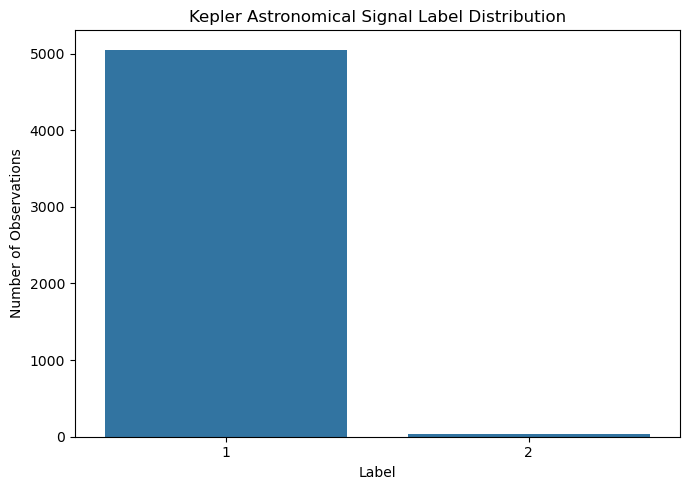

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_train,
    x="LABEL"
)

plt.title("Kepler Astronomical Signal Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

## Stellar Flux Statistical Analysis

The statistical properties of the flux measurements are examined to understand their scale, variability, and extreme values.

Important statistics include:

- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [12]:
flux_statistics = df_train[flux_columns].describe()

display(flux_statistics.iloc[:, :10])

,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,FLUX.10
count,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03
mean,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,1.410852e+02
std,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,1.942289e+04
min,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,-2.223300e+05
25%,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,-2.797500e+01
50%,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,-9.600000e-01
75%,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,2.874500e+01
max,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,1.263870e+06


## Stellar Light-Curve Visualization

The flux measurements are sequential observations of stellar brightness.

For an individual observation, the values from `FLUX.1` through `FLUX.3197` are plotted in sequence to visualize the stellar light curve.

This visualization is important because it allows us to inspect:

- Brightness variations
- Sudden changes
- Signal fluctuations
- Potential transit-like patterns
- Unusual observations

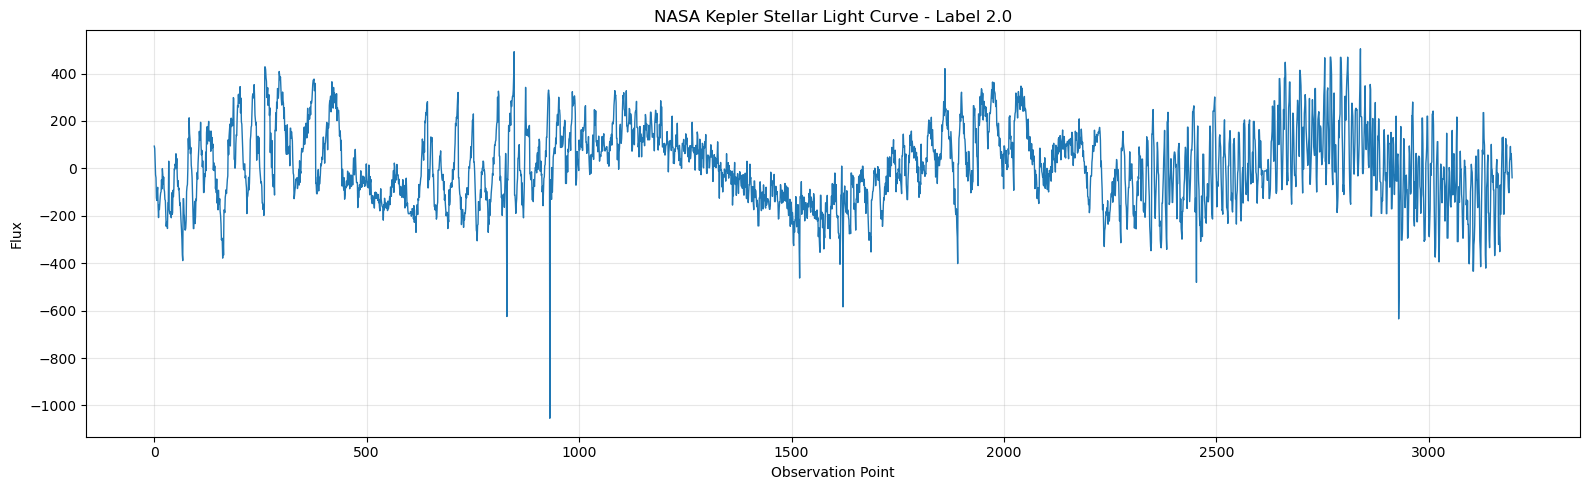

In [13]:
sample = df_train.iloc[0]

light_curve = sample[flux_columns].values

plt.figure(figsize=(16, 5))

plt.plot(
    light_curve,
    linewidth=1
)

plt.title(
    f"NASA Kepler Stellar Light Curve - Label {sample['LABEL']}"
)

plt.xlabel("Observation Point")
plt.ylabel("Flux")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Comparison of Light Curves Across Labels

The next analysis compares representative observations from Label 1 and Label 2.

Because Label 2 is much rarer than Label 1, comparing their signal patterns can help us understand whether their light curves exhibit different characteristics.

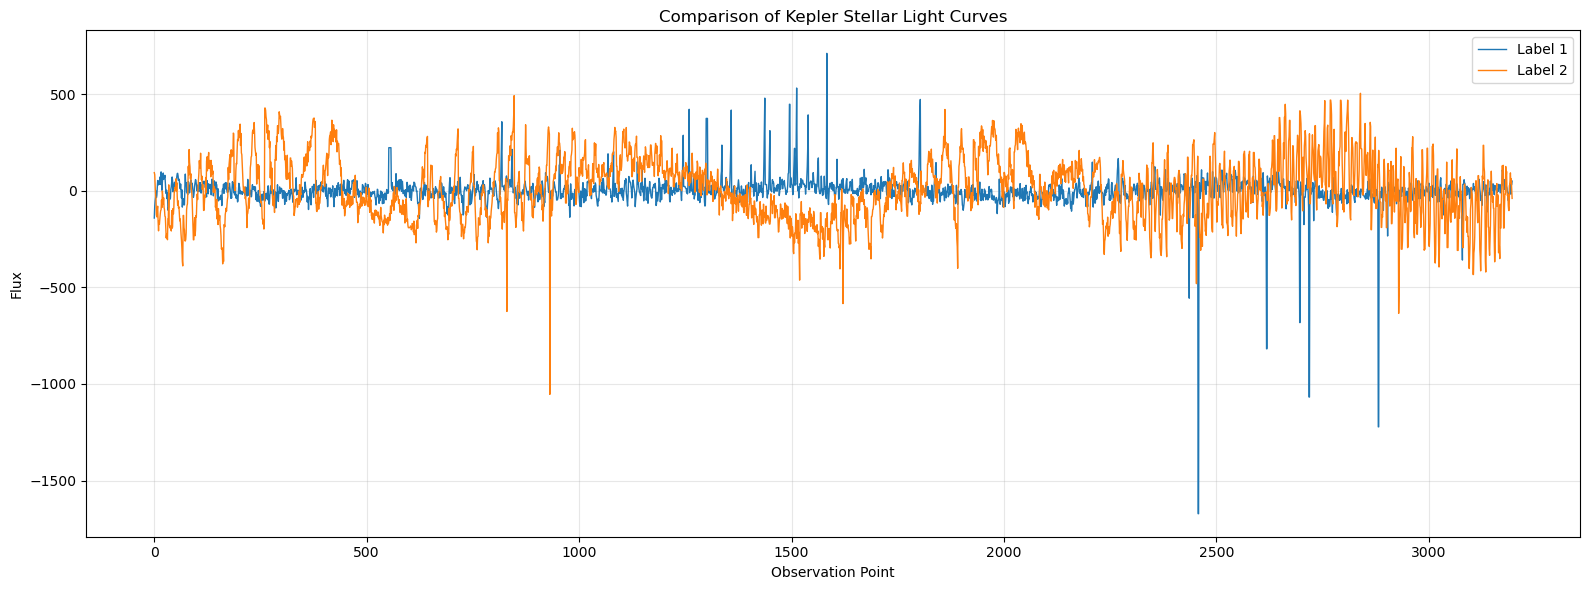

In [14]:
sample_1 = df_train[df_train["LABEL"] == 1].iloc[0]
sample_2 = df_train[df_train["LABEL"] == 2].iloc[0]

curve_1 = sample_1[flux_columns].values
curve_2 = sample_2[flux_columns].values

plt.figure(figsize=(16, 6))

plt.plot(
    curve_1,
    label="Label 1",
    linewidth=1
)

plt.plot(
    curve_2,
    label="Label 2",
    linewidth=1
)

plt.title("Comparison of Kepler Stellar Light Curves")

plt.xlabel("Observation Point")
plt.ylabel("Flux")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Data Preprocessing

## Separating Features and Target

The `LABEL` column represents the target variable, while the `FLUX` columns contain the stellar light-curve measurements used as input features.

We separate the target variable from the input features before applying machine learning preprocessing techniques.

In [15]:
X = df_train.drop("LABEL", axis=1)
y = df_train["LABEL"]

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

Feature shape: (5087, 3197)
Target shape : (5087,)


## Identifying Flux Features

The Kepler dataset contains a large number of flux measurements representing the stellar light curve.

All columns beginning with `FLUX.` are selected as the primary numerical signal features.

In [16]:
# Identify all flux columns

flux_columns = [
    col for col in df_train.columns
    if col.startswith("FLUX.")
]

print("Number of flux features:", len(flux_columns))

print("\nFirst 10 flux columns:")
print(flux_columns[:10])

print("\nLast 5 flux columns:")
print(flux_columns[-5:])

Number of flux features: 3197

First 10 flux columns:
['FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4', 'FLUX.5', 'FLUX.6', 'FLUX.7', 'FLUX.8', 'FLUX.9', 'FLUX.10']

Last 5 flux columns:
['FLUX.3193', 'FLUX.3194', 'FLUX.3195', 'FLUX.3196', 'FLUX.3197']


In [17]:
# Check missing values in flux features

print("Missing values in training flux data:")
print(X[flux_columns].isna().sum().sum())

print("\nMissing values in testing flux data:")
print(df_test[flux_columns].isna().sum().sum())

Missing values in training flux data:
0

Missing values in testing flux data:
0


In [18]:
# Check for infinite values

train_inf = np.isinf(X[flux_columns].to_numpy()).sum()
test_inf = np.isinf(df_test[flux_columns].to_numpy()).sum()

print("Infinite values in training data:", train_inf)
print("Infinite values in testing data :", test_inf)

Infinite values in training data: 0
Infinite values in testing data : 0


## Preparing Feature Matrices

The flux measurements are extracted into separate training and testing feature matrices.

The target variable is available only in the training dataset because the test dataset is used for prediction.

In [19]:
X_train = df_train[flux_columns].copy()
X_test = df_test[flux_columns].copy()

y_train = df_train["LABEL"].copy()

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)

X_train shape: (5087, 3197)
X_test shape : (570, 3197)
y_train shape: (5087,)


## Feature Scaling

The Kepler flux measurements can have different numerical scales.

Standardization is applied so that the features have approximately zero mean and unit variance.

The scaler is fitted only on the training data and then applied to both training and testing data. This prevents information from the test dataset from influencing the preprocessing stage.

In [20]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Scaled training shape: (5087, 3197)
Scaled testing shape : (570, 3197)


## Verifying Feature Scaling

After standardization, the transformed features should have values centered approximately around zero with a standard deviation close to one.

In [21]:
print("Mean of first 5 scaled features:")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nStandard deviation of first 5 scaled features:")
print(X_train_scaled[:, :5].std(axis=0))

Mean of first 5 scaled features:
[-2.79356295e-18  5.58712590e-18  2.79356295e-18  2.79356295e-18
 -2.79356295e-18]

Standard deviation of first 5 scaled features:
[1. 1. 1. 1. 1.]


## Feature Engineering

The Kepler dataset contains 3,197 flux measurements for each stellar observation.

Instead of relying only on the raw flux measurements, additional statistical and signal-based features are engineered to summarize the behavior of each light curve.

These features help describe stellar brightness, variability, possible transit-like dips, and signal strength.

The engineered features will later be used for exploratory analysis, anomaly detection, and machine learning.

In [22]:
X_train_features = pd.DataFrame(index=X_train.index)

# Statistical features
X_train_features["mean_flux"] = X_train.mean(axis=1)

X_train_features["std_flux"] = X_train.std(axis=1)

X_train_features["min_flux"] = X_train.min(axis=1)

X_train_features["max_flux"] = X_train.max(axis=1)

X_train_features["flux_range"] = (
    X_train_features["max_flux"]
    - X_train_features["min_flux"]
)

X_train_features["median_flux"] = X_train.median(axis=1)

X_train_features["flux_q25"] = X_train.quantile(0.25, axis=1)

X_train_features["flux_q75"] = X_train.quantile(0.75, axis=1)

X_train_features["flux_iqr"] = (
    X_train_features["flux_q75"]
    - X_train_features["flux_q25"]
)

# Relative brightness variation
X_train_features["brightness_variation"] = (
    X_train_features["std_flux"]
    / (np.abs(X_train_features["mean_flux"]) + 1e-8)
)

# Transit depth proxy
X_train_features["transit_depth_proxy"] = (
    X_train_features["median_flux"]
    - X_train_features["min_flux"]
)

# Signal-to-noise proxy
X_train_features["snr_proxy"] = (
    np.abs(X_train_features["median_flux"])
    / (X_train_features["std_flux"] + 1e-8)
)

print("Feature Engineering Completed Successfully!")

print("\nShape:")
print(X_train_features.shape)

print("\nFeature Names:")
print(X_train_features.columns.tolist())

print("\nFirst 5 Rows:")
display(X_train_features.head())

Feature Engineering Completed Successfully!

Shape:
(5087, 12)

Feature Names:
['mean_flux', 'std_flux', 'min_flux', 'max_flux', 'flux_range', 'median_flux', 'flux_q25', 'flux_q75', 'flux_iqr', 'brightness_variation', 'transit_depth_proxy', 'snr_proxy']

First 5 Rows:


,mean_flux,std_flux,min_flux,max_flux,flux_range,median_flux,flux_q25,flux_q75,flux_iqr,brightness_variation,transit_depth_proxy,snr_proxy
0,9.953857,160.728487,-1053.97,504.46,1558.43,-0.01,-103.40,118.68,222.08,16.147358,1053.96,0.000062
1,-7.427932,60.011024,-371.27,252.64,623.91,0.01,-25.18,21.43,46.61,8.079102,371.28,0.000167
2,8.189087,281.876484,-874.95,1274.59,2149.54,-0.08,-129.67,158.31,287.98,34.420992,874.87,0.000284
3,-4.646587,103.238723,-268.41,370.29,638.70,-0.01,-78.19,69.52,147.71,22.218181,268.40,0.000097
4,-14.240660,407.121292,-1808.76,924.32,2733.08,0.02,-268.09,315.40,583.49,28.588653,1808.78,0.000049


##  PCA Analysis

Principal Component Analysis (PCA) is a dimensionality-reduction technique used to transform a large number of correlated features into a smaller set of principal components.

In this project, the original Kepler light-curve data contains 3,197 flux measurements for each observation. PCA helps reduce the dimensionality of the data while preserving the most important variation in the stellar light-curve signals.

PCA is useful in this project because:

- The Kepler dataset contains a very large number of flux measurements.
- Many flux measurements can contain correlated information.
- Reducing the dimensionality makes machine-learning analysis more efficient.
- Principal components can help visualize patterns and unusual observations.
- The reduced feature space can later be used for anomaly detection.

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use the engineered features for PCA
X_pca_input = X_train_features.copy()

print("PCA input shape:")
print(X_pca_input.shape)

print("\nPCA input features:")
print(X_pca_input.columns.tolist())

PCA input shape:
(5087, 12)

PCA input features:
['mean_flux', 'std_flux', 'min_flux', 'max_flux', 'flux_range', 'median_flux', 'flux_q25', 'flux_q75', 'flux_iqr', 'brightness_variation', 'transit_depth_proxy', 'snr_proxy']


## Feature Scaling for PCA

PCA is sensitive to the scale of the input variables.

The engineered features have different numerical ranges. For example, flux range and signal-to-noise ratio may have very different magnitudes.

Therefore, StandardScaler is used to standardize the features so that each feature has:

- Mean approximately equal to 0
- Standard deviation approximately equal to 1

This prevents features with larger numerical values from dominating the PCA transformation.

In [24]:
pca_scaler = StandardScaler()

X_pca_scaled = pca_scaler.fit_transform(X_pca_input)

print("Scaled PCA data shape:")
print(X_pca_scaled.shape)

print("\nMean of scaled features:")
print(X_pca_scaled.mean(axis=0))

print("\nStandard deviation of scaled features:")
print(X_pca_scaled.std(axis=0))

Scaled PCA data shape:
(5087, 12)

Mean of scaled features:
[ 4.19034442e-18  9.07907958e-18  4.19034442e-18 -2.79356295e-18
  4.19034442e-18 -4.19034442e-18 -2.79356295e-18 -2.09517221e-18
  6.28551663e-18  4.19034442e-18 -5.58712590e-18 -1.67613777e-17]

Standard deviation of scaled features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [25]:
pca = PCA()

X_pca = pca.fit_transform(X_pca_scaled)

print("PCA transformed shape:")
print(X_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

PCA transformed shape:
(5087, 12)

Explained variance ratio:
[5.41114839e-01 1.03580065e-01 1.01338737e-01 9.11372056e-02
 8.33327676e-02 6.52322108e-02 9.04346828e-03 3.74193806e-03
 1.47876815e-03 3.53972418e-17 0.00000000e+00 0.00000000e+00]


In [26]:
explained_variance = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

for i, value in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {value:.4f} ({value*100:.2f}%)")

PC1: 0.5411 (54.11%)
PC2: 0.6447 (64.47%)
PC3: 0.7460 (74.60%)
PC4: 0.8372 (83.72%)
PC5: 0.9205 (92.05%)
PC6: 0.9857 (98.57%)
PC7: 0.9948 (99.48%)
PC8: 0.9985 (99.85%)
PC9: 1.0000 (100.00%)
PC10: 1.0000 (100.00%)
PC11: 1.0000 (100.00%)
PC12: 1.0000 (100.00%)


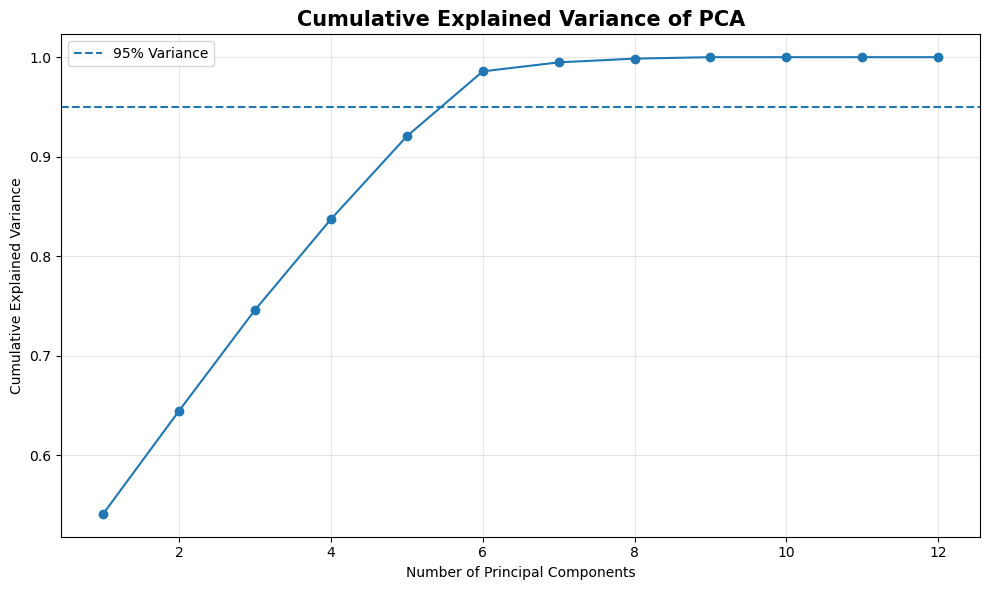

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.title(
    "Cumulative Explained Variance of PCA",
    fontsize=15,
    fontweight="bold"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of PCA components selected:", n_components)

print(
    f"Cumulative explained variance: "
    f"{cumulative_variance[n_components - 1] * 100:.2f}%"
)

Number of PCA components selected: 6
Cumulative explained variance: 98.57%


In [29]:
pca_reduced = PCA(
    n_components=n_components
)

X_train_pca = pca_reduced.fit_transform(
    X_pca_scaled
)

print("Original feature shape:")
print(X_pca_input.shape)

print("\nReduced PCA shape:")
print(X_train_pca.shape)

print("\nNumber of retained components:")
print(n_components)

Original feature shape:
(5087, 12)

Reduced PCA shape:
(5087, 6)

Number of retained components:
6


In [30]:
pca_columns = [
    f"PC{i}"
    for i in range(1, n_components + 1)
]

X_train_pca_df = pd.DataFrame(
    X_train_pca,
    columns=pca_columns,
    index=X_train.index
)

print("PCA DataFrame shape:")
print(X_train_pca_df.shape)

display(X_train_pca_df.head())

PCA DataFrame shape:
(5087, 6)


,PC1,PC2,PC3,PC4,PC5,PC6
0,-0.148933,-0.352552,-1.031691,0.266867,-0.022357,1.052203
1,-0.169923,-0.944952,-2.708146,0.701032,-0.022023,3.009893
2,-0.126700,-1.762664,-4.979636,1.224447,-0.014881,4.785962
3,-0.166527,-0.563356,-1.607117,0.424177,-0.021010,1.676249
4,-0.115385,-0.248729,-0.706026,0.184606,-0.021310,0.929933


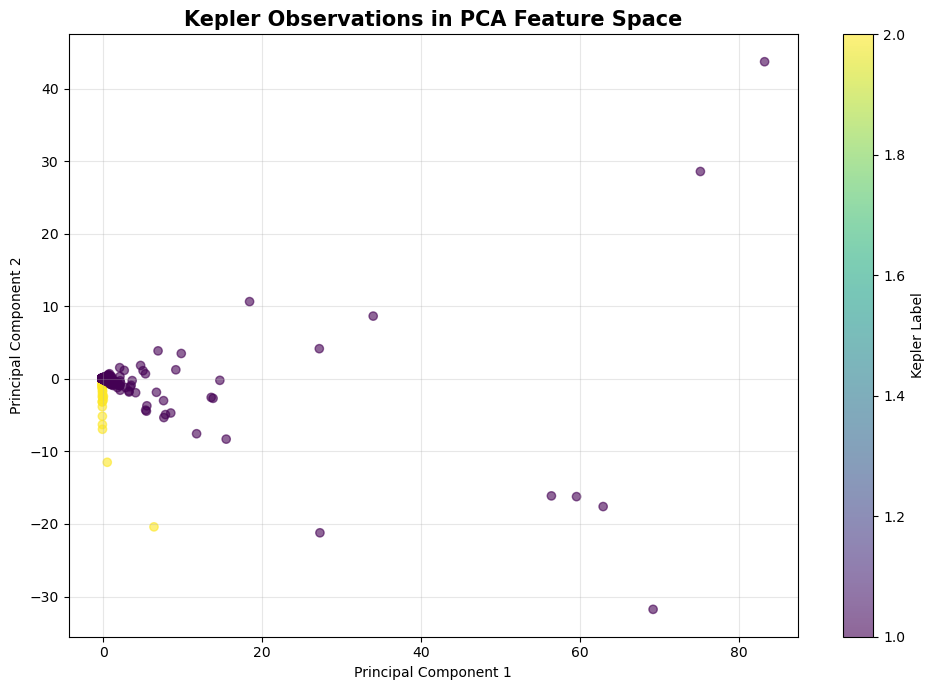

In [31]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_train_pca_df["PC1"],
    X_train_pca_df["PC2"],
    c=y_train,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Kepler Observations in PCA Feature Space",
    fontsize=15,
    fontweight="bold"
)

plt.colorbar(
    scatter,
    label="Kepler Label"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##  Anomaly Detection

Anomaly detection is used to identify observations that differ significantly from the normal pattern of Kepler stellar light-curve observations.

In this project, Isolation Forest is used as an unsupervised anomaly-detection algorithm.

Isolation Forest works by randomly selecting features and split points to isolate individual observations. Unusual observations are generally easier to isolate because they differ from the majority of the data.

The anomaly-detection process uses the PCA-reduced feature representation created in the previous section.

The detected anomalies are then compared with the available Kepler labels to understand whether unusual observations correspond to potential astronomical candidates.

In [32]:
from sklearn.ensemble import IsolationForest

print("Isolation Forest imported successfully.")

Isolation Forest imported successfully.


In [33]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_pca)

print("Isolation Forest training completed successfully.")

Isolation Forest training completed successfully.


In [34]:
anomaly_prediction = iso_forest.predict(X_train_pca)

# Isolation Forest:
#  1  = normal observation
# -1  = anomaly

anomaly_labels = np.where(
    anomaly_prediction == -1,
    1,
    0
)

print("Anomaly prediction completed.")

print("\nNormal observations:", np.sum(anomaly_labels == 0))
print("Anomalous observations:", np.sum(anomaly_labels == 1))

Anomaly prediction completed.

Normal observations: 5036
Anomalous observations: 51


In [35]:
raw_scores = iso_forest.decision_function(X_train_pca)

# Convert the Isolation Forest score so that
# larger values represent more anomalous observations
anomaly_score = -raw_scores

print("Anomaly scores calculated successfully.")

print("\nFirst 10 anomaly scores:")
print(anomaly_score[:10])

Anomaly scores calculated successfully.

First 10 anomaly scores:
[-0.07844219 -0.00527303  0.04482128 -0.04180915 -0.08402206 -0.02200046
 -0.42664546 -0.04615178  0.07645709  0.07464398]


In [36]:
anomaly_results = pd.DataFrame({
    "LABEL": y_train.values,
    "anomaly_prediction": anomaly_labels,
    "anomaly_score": anomaly_score
})

print("Anomaly results shape:")
print(anomaly_results.shape)

display(anomaly_results.head())

Anomaly results shape:
(5087, 3)


,LABEL,anomaly_prediction,anomaly_score
0,2,0,-0.078442
1,2,0,-0.005273
2,2,1,0.044821
3,2,0,-0.041809
4,2,0,-0.084022


In [37]:
print("Anomaly Distribution:")

print(
    anomaly_results["anomaly_prediction"]
    .value_counts()
    .rename({
        0: "Normal",
        1: "Anomaly"
    })
)

Anomaly Distribution:
anomaly_prediction
Normal     5036
Anomaly      51
Name: count, dtype: int64


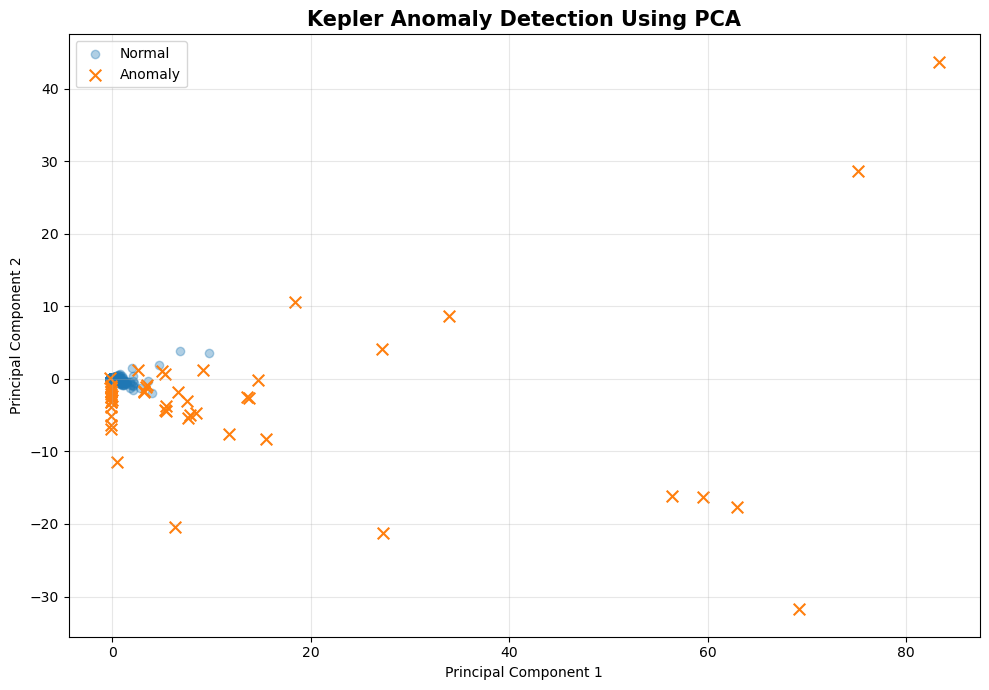

In [38]:
plt.figure(figsize=(10, 7))

normal_mask = anomaly_results["anomaly_prediction"] == 0
anomaly_mask = anomaly_results["anomaly_prediction"] == 1

plt.scatter(
    X_train_pca[normal_mask, 0],
    X_train_pca[normal_mask, 1],
    alpha=0.35,
    label="Normal"
)

plt.scatter(
    X_train_pca[anomaly_mask, 0],
    X_train_pca[anomaly_mask, 1],
    marker="x",
    s=70,
    label="Anomaly"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Kepler Anomaly Detection Using PCA",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
anomaly_label_table = pd.crosstab(
    anomaly_results["LABEL"],
    anomaly_results["anomaly_prediction"]
)

anomaly_label_table.columns = [
    "Normal",
    "Anomaly"
]

print("Kepler Label vs Anomaly Detection:")
display(anomaly_label_table)

Kepler Label vs Anomaly Detection:


,Normal,Anomaly
LABEL,,
1,5018,32
2,18,19


In [40]:
candidate_anomalies = anomaly_results[
    (anomaly_results["LABEL"] == 2) &
    (anomaly_results["anomaly_prediction"] == 1)
]

candidate_count = (anomaly_results["LABEL"] == 2).sum()

detected_candidate_count = len(candidate_anomalies)

print("Total candidate observations:", candidate_count)

print(
    "Candidate observations detected as anomalies:",
    detected_candidate_count
)

if candidate_count > 0:
    detection_rate = (
        detected_candidate_count / candidate_count
    ) * 100

    print(
        f"Candidate anomaly detection rate: "
        f"{detection_rate:.2f}%"
    )

Total candidate observations: 37
Candidate observations detected as anomalies: 19
Candidate anomaly detection rate: 51.35%


In [41]:
top_anomalies = (
    anomaly_results
    .sort_values(
        by="anomaly_score",
        ascending=False
    )
    .head(20)
)

print("Top 20 Most Anomalous Kepler Observations:")

display(top_anomalies)

Top 20 Most Anomalous Kepler Observations:


,LABEL,anomaly_prediction,anomaly_score
954,1,1,0.118888
497,1,1,0.106281
21,2,1,0.100756
1668,1,1,0.098383
31,2,1,0.098168
3340,1,1,0.097653
17,2,1,0.096486
26,2,1,0.093615
1951,1,1,0.093386
2739,1,1,0.089167


## Classification

The classification stage uses supervised machine learning to distinguish between the two classes present in the Kepler dataset.

The target variable is the LABEL column.

The dataset is highly imbalanced, with the majority of observations belonging to Label 1 and only a small number belonging to Label 2.

Therefore, accuracy alone is not considered a reliable evaluation metric.

The classification stage focuses on identifying the minority candidate class while maintaining reasonable overall performance.

The engineered features generated earlier are used as the input variables for classification.

In [42]:
print("Classification feature shape:")
print(X_train_features.shape)

print("\nNumber of features:")
print(X_train_features.shape[1])

print("\nTarget shape:")
print(y_train.shape)

print("\nTarget distribution:")
print(y_train.value_counts())

Classification feature shape:
(5087, 12)

Number of features:
12

Target shape:
(5087,)

Target distribution:
LABEL
1    5050
2      37
Name: count, dtype: int64


In [43]:
from sklearn.model_selection import train_test_split

X_class_train, X_class_valid, y_class_train, y_class_valid = train_test_split(
    X_train_features,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training data shape:")
print(X_class_train.shape)

print("\nValidation data shape:")
print(X_class_valid.shape)

print("\nTraining label distribution:")
print(y_class_train.value_counts())

print("\nValidation label distribution:")
print(y_class_valid.value_counts())

Training data shape:
(4069, 12)

Validation data shape:
(1018, 12)

Training label distribution:
LABEL
1    4039
2      30
Name: count, dtype: int64

Validation label distribution:
LABEL
1    1011
2       7
Name: count, dtype: int64


In [44]:
from sklearn.preprocessing import StandardScaler

classification_scaler = StandardScaler()

X_class_train_scaled = classification_scaler.fit_transform(
    X_class_train
)

X_class_valid_scaled = classification_scaler.transform(
    X_class_valid
)

print("Feature scaling completed successfully.")

print("\nScaled training shape:")
print(X_class_train_scaled.shape)

print("\nScaled validation shape:")
print(X_class_valid_scaled.shape)

Feature scaling completed successfully.

Scaled training shape:
(4069, 12)

Scaled validation shape:
(1018, 12)


In [45]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_class_train_scaled,
    y_class_train
)

print("Logistic Regression training completed successfully.")

Logistic Regression training completed successfully.


In [46]:
y_pred_logistic = logistic_model.predict(
    X_class_valid_scaled
)

print("Predictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred_logistic[:20])

Predictions generated successfully.

First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [47]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_class_train,
    y_class_train
)

print("Random Forest training completed successfully.")

Random Forest training completed successfully.


In [48]:
y_pred_rf = random_forest_model.predict(
    X_class_valid
)

print("Random Forest predictions generated successfully.")

print("\nFirst 20 predictions:")
print(y_pred_rf[:20])

Random Forest predictions generated successfully.

First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [49]:
print("Logistic Regression prediction distribution:")
print(pd.Series(y_pred_logistic).value_counts())

print("\nRandom Forest prediction distribution:")
print(pd.Series(y_pred_rf).value_counts())

Logistic Regression prediction distribution:
1    1011
2       7
Name: count, dtype: int64

Random Forest prediction distribution:
1    1012
2       6
Name: count, dtype: int64


##  Model Evaluation

Model evaluation is used to measure how well the classification models distinguish between the two Kepler classes.

The following evaluation metrics are used:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

Since the Kepler dataset is highly imbalanced, particular attention is given to the performance of the minority class (LABEL = 2).

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("Evaluation metrics imported successfully.")

Evaluation metrics imported successfully.


##  Logistic Regression Evaluation

The Logistic Regression model is evaluated using the validation dataset.

Precision measures how many observations predicted as the candidate class are actually candidates.

Recall measures how many of the actual candidate observations are successfully identified.

F1-score combines precision and recall into a single measure.

In [51]:
logistic_accuracy = accuracy_score(
    y_class_valid,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_class_valid,
    y_pred_logistic,
    pos_label=2,
    zero_division=0
)

logistic_recall = recall_score(
    y_class_valid,
    y_pred_logistic,
    pos_label=2,
    zero_division=0
)

logistic_f1 = f1_score(
    y_class_valid,
    y_pred_logistic,
    pos_label=2,
    zero_division=0
)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-score : {logistic_f1:.4f}")

Logistic Regression Performance
--------------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000


In [52]:
rf_accuracy = accuracy_score(
    y_class_valid,
    y_pred_rf
)

rf_precision = precision_score(
    y_class_valid,
    y_pred_rf,
    pos_label=2,
    zero_division=0
)

rf_recall = recall_score(
    y_class_valid,
    y_pred_rf,
    pos_label=2,
    zero_division=0
)

rf_f1 = f1_score(
    y_class_valid,
    y_pred_rf,
    pos_label=2,
    zero_division=0
)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.9990
Precision: 1.0000
Recall   : 0.8571
F1-score : 0.9231


##  Classification Reports

Classification reports provide precision, recall and F1-score for each Kepler class.

The performance of LABEL = 2 is especially important because it represents the minority class in this dataset.

In [53]:
print("Logistic Regression Classification Report")
print("==========================================")

print(
    classification_report(
        y_class_valid,
        y_pred_logistic,
        labels=[1, 2],
        target_names=[
            "Normal (Label 1)",
            "Candidate (Label 2)"
        ],
        zero_division=0
    )
)

Logistic Regression Classification Report
                     precision    recall  f1-score   support

   Normal (Label 1)       1.00      1.00      1.00      1011
Candidate (Label 2)       1.00      1.00      1.00         7

           accuracy                           1.00      1018
          macro avg       1.00      1.00      1.00      1018
       weighted avg       1.00      1.00      1.00      1018



##  Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each class.

For the Kepler candidate class:

- True Positive (TP): Candidate correctly identified as candidate.
- False Positive (FP): Normal observation incorrectly classified as candidate.
- False Negative (FN): Candidate incorrectly classified as normal.
- True Negative (TN): Normal observation correctly identified as normal.

The confusion matrix is particularly useful for understanding whether the model is missing rare candidate observations.

In [54]:
cm_logistic = confusion_matrix(
    y_class_valid,
    y_pred_logistic,
    labels=[1, 2]
)

print("Logistic Regression Confusion Matrix:")
print(cm_logistic)

Logistic Regression Confusion Matrix:
[[1011    0]
 [   0    7]]


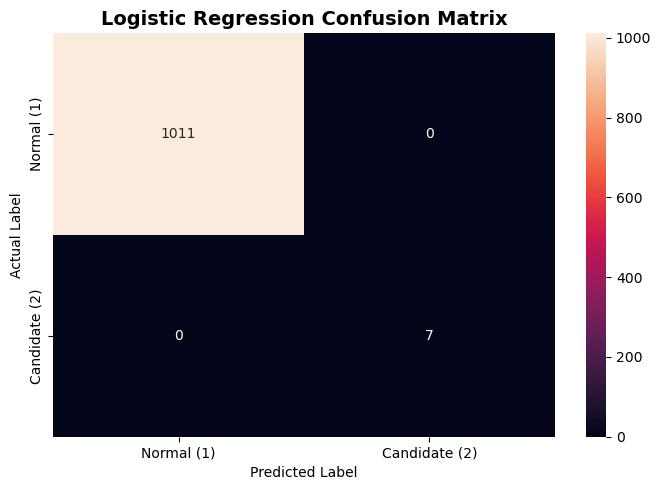

In [55]:
## 17.6 LOGISTIC REGRESSION CONFUSION MATRIX PLOT

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=[
        "Normal (1)",
        "Candidate (2)"
    ],
    yticklabels=[
        "Normal (1)",
        "Candidate (2)"
]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title(
    "Logistic Regression Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [56]:
## RANDOM FOREST CONFUSION MATRIX

cm_rf = confusion_matrix(
    y_class_valid,
    y_pred_rf,
    labels=[1, 2]
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

Random Forest Confusion Matrix:
[[1011    0]
 [   1    6]]


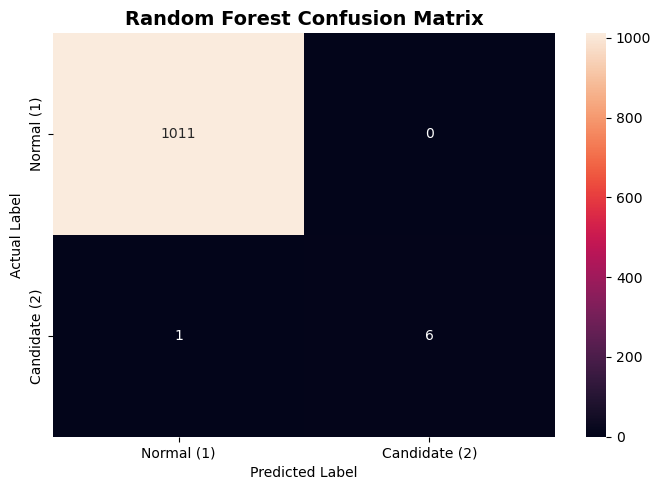

In [57]:
## RANDOM FOREST CONFUSION MATRIX PLOT

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=[
        "Normal (1)",
        "Candidate (2)"
    ],
    yticklabels=[
        "Normal (1)",
        "Candidate (2)"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## ROC-AUC Evaluation

ROC-AUC measures the ability of a classifier to distinguish between the two classes using prediction scores.

The ROC curve represents the relationship between the true-positive rate and false-positive rate at different classification thresholds.

ROC-AUC is calculated using the predicted probability for LABEL = 2.

In [58]:
logistic_prob = logistic_model.predict_proba(
    X_class_valid_scaled
)[:, 1]

rf_prob = random_forest_model.predict_proba(
    X_class_valid
)[:, 1]

logistic_auc = roc_auc_score(
    (y_class_valid == 2).astype(int),
    logistic_prob
)

rf_auc = roc_auc_score(
    (y_class_valid == 2).astype(int),
    rf_prob
)

print("ROC-AUC Scores")
print("==============")
print(f"Logistic Regression: {logistic_auc:.4f}")
print(f"Random Forest      : {rf_auc:.4f}")

ROC-AUC Scores
Logistic Regression: 1.0000
Random Forest      : 1.0000


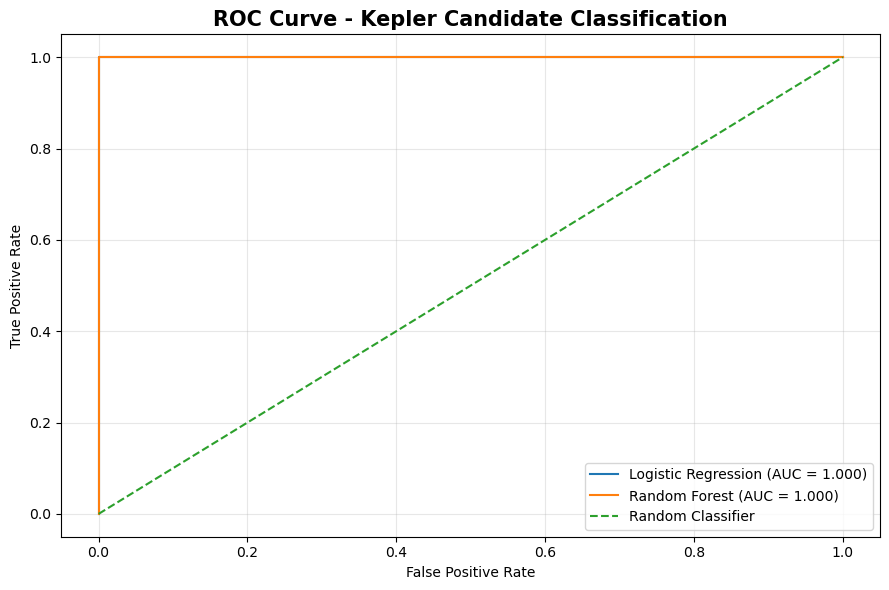

In [59]:
y_valid_binary = (
    y_class_valid == 2
).astype(int)

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_valid_binary,
    logistic_prob
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_valid_binary,
    rf_prob
)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Kepler Candidate Classification",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Model Performance Comparison

The performance of Logistic Regression and Random Forest is compared using multiple evaluation metrics.

Because the dataset is highly imbalanced, F1-score, recall and precision for LABEL = 2 are especially important when selecting the final model.

In [60]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]
})

display(
    model_comparison.round(4)
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.000,1.0,1.0000,1.0000,1.0
1,Random Forest,0.999,1.0,0.8571,0.9231,1.0


In [61]:
display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.000,1.0,1.0000,1.0000,1.0
1,Random Forest,0.999,1.0,0.8571,0.9231,1.0


In [62]:
best_model_name = model_comparison.loc[
    model_comparison["F1-Score"].idxmax(),
    "Model"
]

print("Best model based on minority-class F1-score:")
print(best_model_name)

Best model based on minority-class F1-score:
Logistic Regression


## Candidate Signal Analysis

Candidate Signal Analysis is performed to investigate the observations identified as potential exoplanet candidates.

The classification model predicts the class of each observation. Observations predicted as LABEL = 2 are treated as candidate signals for further analysis.

The original Kepler FLUX measurements are then examined to understand the brightness variation and identify unusual transit-like patterns.

This analysis connects the machine learning predictions with the underlying stellar light-curve data.

In [63]:
# Scale the complete feature dataset
X_train_features_scaled = classification_scaler.transform(
    X_train_features
)

# Generate predictions using the selected Logistic Regression model
final_predictions = logistic_model.predict(
    X_train_features_scaled
)

print("Final predictions generated successfully.")

print("\nPrediction distribution:")
print(pd.Series(final_predictions).value_counts())

Final predictions generated successfully.

Prediction distribution:
1    5056
2      31
Name: count, dtype: int64


In [64]:
candidate_indices = np.where(
    final_predictions == 2
)[0]

print("Number of candidate observations:")
print(len(candidate_indices))

print("\nFirst 20 candidate indices:")
print(candidate_indices[:20])

Number of candidate observations:
31

First 20 candidate indices:
[ 0  1  2  3  4  5  7  8  9 10 11 12 13 14 17 20 21 22 23 24]


In [65]:
flux_columns = [
    col for col in df_train.columns
    if col.startswith("FLUX.")
]

candidate_flux_data = df_train.iloc[
    candidate_indices
][flux_columns]

print("Candidate FLUX dataset shape:")
print(candidate_flux_data.shape)

print("\nNumber of FLUX measurements:")
print(len(flux_columns))

Candidate FLUX dataset shape:
(31, 3197)

Number of FLUX measurements:
3197


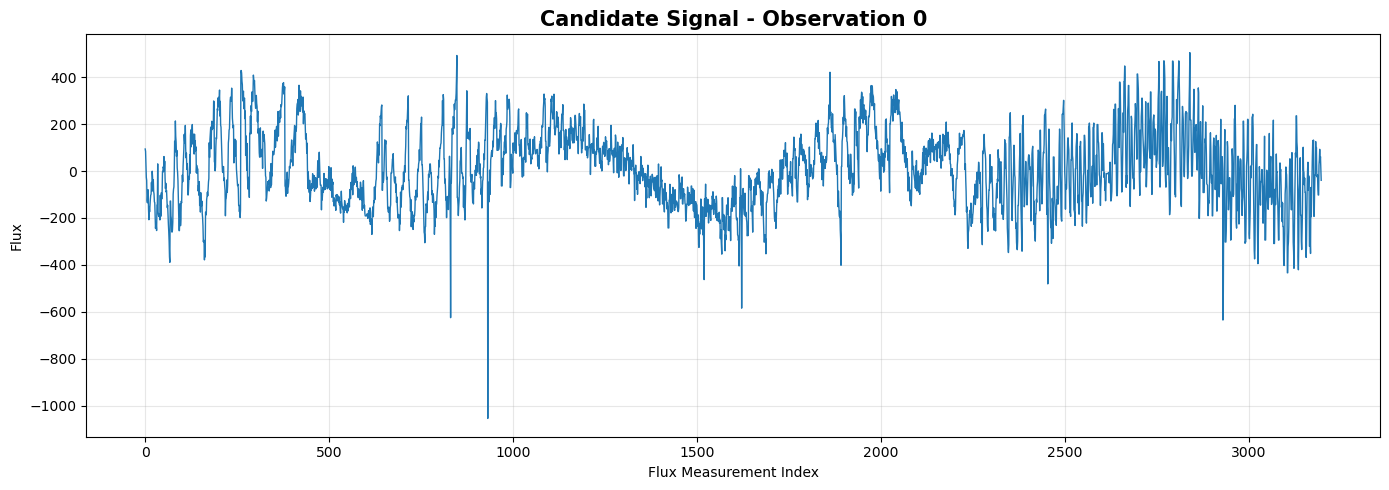

In [66]:
candidate_number = 0

candidate_row = candidate_flux_data.iloc[
    candidate_number
].values

time_axis = np.arange(
    len(candidate_row)
)

plt.figure(figsize=(14, 5))

plt.plot(
    time_axis,
    candidate_row,
    linewidth=1
)

plt.xlabel("Flux Measurement Index")
plt.ylabel("Flux")

plt.title(
    f"Candidate Signal - Observation {candidate_indices[candidate_number]}",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

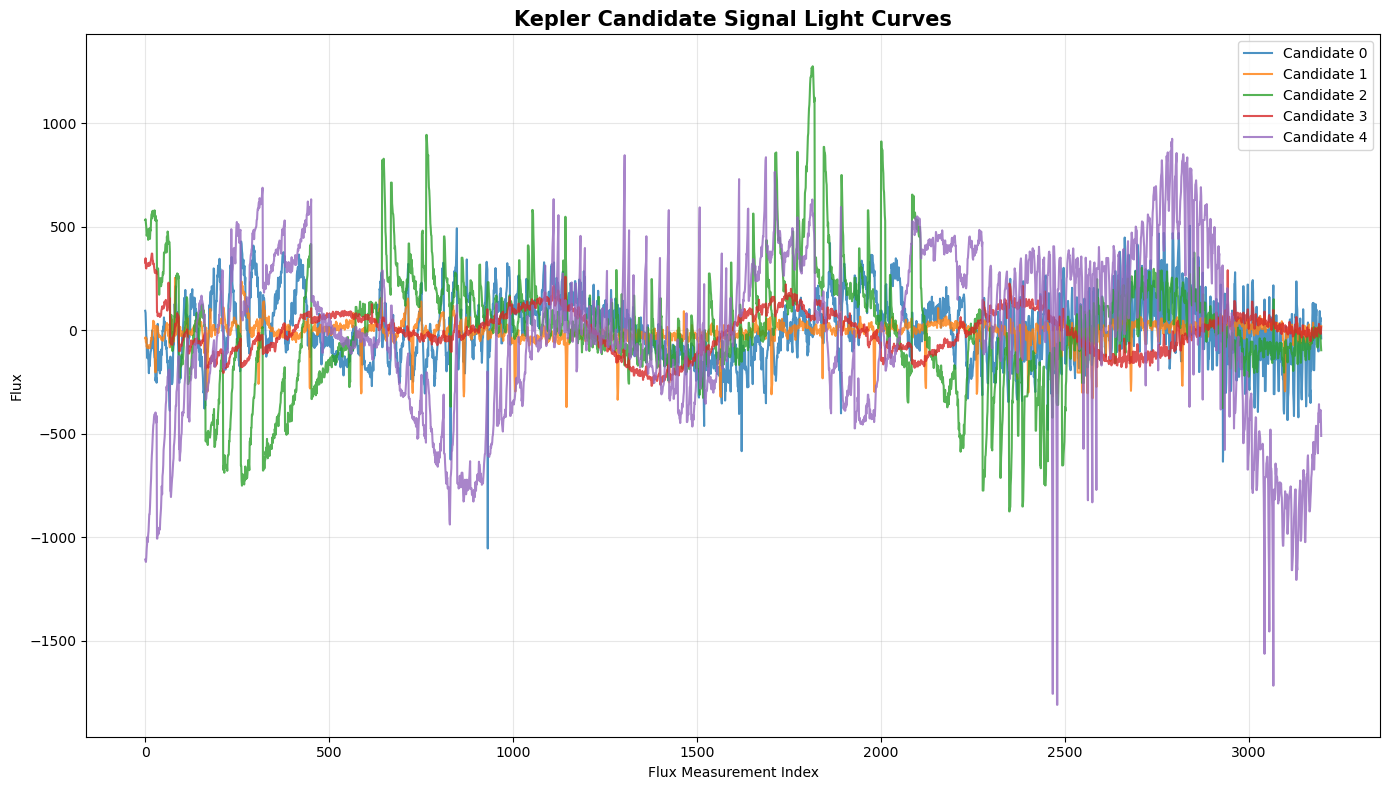

In [67]:
number_of_candidates = min(
    5,
    len(candidate_flux_data)
)

plt.figure(figsize=(14, 8))

for i in range(number_of_candidates):

    candidate_signal = candidate_flux_data.iloc[i].values

    plt.plot(
        time_axis,
        candidate_signal,
        label=f"Candidate {candidate_indices[i]}",
        alpha=0.8
    )

plt.xlabel("Flux Measurement Index")
plt.ylabel("Flux")

plt.title(
    "Kepler Candidate Signal Light Curves",
    fontsize=15,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
candidate_features = X_train_features.iloc[
    candidate_indices
].copy()

print("Candidate feature statistics:")
display(
    candidate_features.describe().round(4)
)

Candidate feature statistics:


,mean_flux,std_flux,min_flux,max_flux,flux_range,median_flux,flux_q25,flux_q75,flux_iqr,brightness_variation,transit_depth_proxy,snr_proxy
count,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000,31.0000
mean,-55.2793,1307.0876,-5095.1526,6012.3997,11107.5523,-0.4600,-957.5923,879.9503,1837.5426,59.4232,5094.6926,0.0004
std,225.1868,5353.9013,21072.5629,26885.1024,47942.5700,2.4134,4037.0154,3627.9543,7663.7826,135.8343,21070.2222,0.0003
min,-1206.4103,18.7002,-118381.3000,171.2800,272.8900,-13.0200,-22537.8000,7.1300,14.9300,3.9241,93.9300,0.0000
25%,-16.8142,52.5258,-2199.4500,369.1500,677.6300,-0.0350,-170.3150,29.0300,64.1200,8.7321,290.3250,0.0001
50%,-3.9696,155.6843,-769.3900,819.7500,2023.6500,-0.0100,-73.3700,69.5200,147.7100,14.8472,769.4000,0.0002
75%,2.3731,414.4395,-290.3250,1586.9550,3230.3150,0.0150,-35.0900,183.8800,354.1950,24.7957,2199.4200,0.0005
max,209.1159,29998.7546,-93.9100,150725.8000,269107.1000,1.0900,-7.8000,20264.4200,42802.2200,627.8456,118368.2800,0.0012


In [69]:
normal_features = X_train_features[
    y_train == 1
]

candidate_features_actual = X_train_features[
    y_train == 2
]

comparison = pd.DataFrame({
    "Normal (Label 1)": normal_features.mean(),
    "Candidate (Label 2)": candidate_features_actual.mean()
})

display(
    comparison.round(4)
)

,Normal (Label 1),Candidate (Label 2)
mean_flux,131.7174,-47.1115
std_flux,1267.3186,1113.5995
min_flux,-3393.8382,-4347.3703
max_flux,5291.5259,5161.3616
flux_range,8685.3641,9508.7319
median_flux,0.0000,-0.3854
flux_q25,-637.6612,-810.7111
flux_q75,713.1744,746.9781
flux_iqr,1350.8356,1557.6892
brightness_variation,190.5007,56.7336


In [70]:
important_features = [
    "std_flux",
    "flux_range",
    "brightness_variation",
    "transit_depth_proxy",
    "snr_proxy"
]

signal_comparison = comparison.loc[
    important_features
]

display(
    signal_comparison.round(4)
)

,Normal (Label 1),Candidate (Label 2)
std_flux,1267.3186,1113.5995
flux_range,8685.3641,9508.7319
brightness_variation,190.5007,56.7336
transit_depth_proxy,3393.8382,4346.9849
snr_proxy,0.0000,0.0003


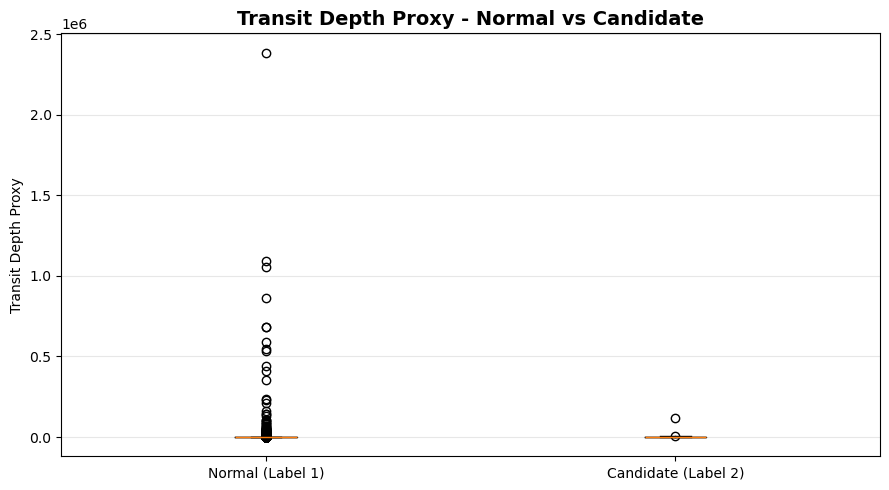

In [71]:
plt.figure(figsize=(9, 5))

plt.boxplot(
    [
        normal_features["transit_depth_proxy"],
        candidate_features_actual["transit_depth_proxy"]
    ],
    labels=[
        "Normal (Label 1)",
        "Candidate (Label 2)"
    ]
)

plt.ylabel("Transit Depth Proxy")

plt.title(
    "Transit Depth Proxy - Normal vs Candidate",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

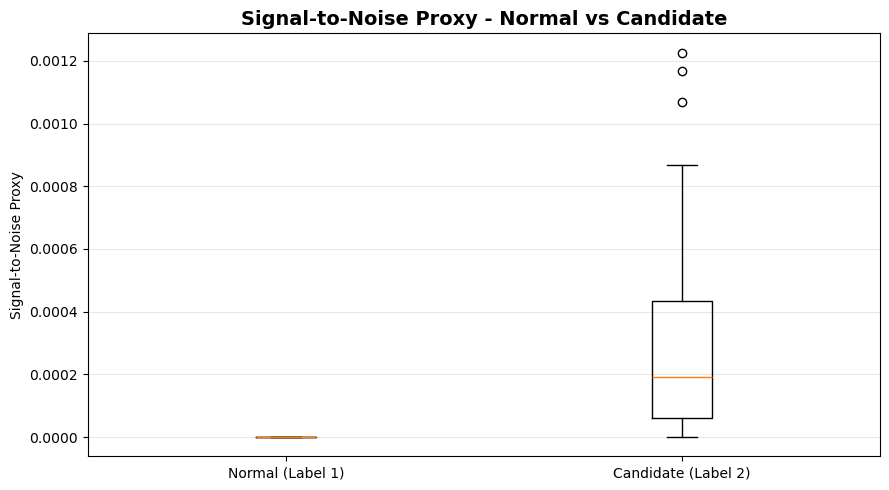

In [72]:
plt.figure(figsize=(9, 5))

plt.boxplot(
    [
        normal_features["snr_proxy"],
        candidate_features_actual["snr_proxy"]
    ],
    labels=[
        "Normal (Label 1)",
        "Candidate (Label 2)"
    ]
)

plt.ylabel("Signal-to-Noise Proxy")

plt.title(
    "Signal-to-Noise Proxy - Normal vs Candidate",
    fontsize=14,
    fontweight="bold"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

##  Candidate Signal Analysis Summary

Candidate observations identified by the Logistic Regression model were extracted and analyzed using their original Kepler FLUX measurements.

The candidate light curves were visualized to inspect unusual brightness patterns.

Statistical features such as flux variation, flux range, transit-depth proxy and signal-to-noise proxy were compared between normal and candidate observations.

This analysis provides an interpretable connection between the machine learning predictions and the underlying stellar light-curve characteristics.

The identified observations should be considered potential candidates rather than confirmed exoplanets, since confirmation requires additional astronomical validation.

## Final Results

The NASA's Kepler Exoplanet Candidate Detection Using Machine Learning project was developed to analyze stellar light-curve observations and identify unusual patterns and potential exoplanet candidate signals.

The project includes data understanding, data quality assessment, exploratory data analysis, preprocessing, feature engineering, dimensionality reduction using PCA, anomaly detection using Isolation Forest, supervised classification using Logistic Regression and Random Forest, model evaluation, and candidate signal analysis.

The final workflow is designed to identify unusual stellar observations and potential transit-like candidate signals from Kepler flux measurements for further investigation.

## Project Outcome

The project successfully developed an end-to-end machine learning workflow for NASA Kepler stellar light-curve analysis.

The workflow included:

1. Loading and understanding Kepler observations
2. Checking data quality
3. Exploring class distribution and flux behavior
4. Preprocessing the light-curve data
5. Engineering statistical and signal-related features
6. Applying PCA for dimensionality reduction and visualization
7. Performing anomaly detection
8. Training classification models
9. Comparing model performance
10. Selecting Logistic Regression as the final classification model
11. Identifying potential candidate observations
12. Analyzing candidate light curves

The final workflow provides a machine-learning-based approach for identifying unusual stellar observations and potential transit-like candidate signals from Kepler flux data.

## Final Conclusion

The NASA's Kepler Exoplanet Candidate Detection Using Machine Learning project demonstrates how machine learning can be applied to astronomical time-series data to analyze stellar light curves and identify unusual observations and potential candidate signals.

By transforming thousands of FLUX measurements into meaningful statistical and signal-related features, the project enables the analysis of stellar brightness patterns using machine learning techniques.

Logistic Regression provided the best classification performance among the evaluated models on the validation data, while Isolation Forest-based anomaly detection and candidate signal analysis provided additional approaches for investigating unusual stellar observations.

The project does not claim to confirm new exoplanets. Instead, it provides a data-driven screening approach for identifying potential candidate signals that can be investigated further using appropriate astronomical validation techniques.


## Keywords

NASA Kepler, Exoplanet Candidate Detection, Stellar Light Curves,
Astronomical Anomaly Detection, Machine Learning, Time-Series Analysis,
Feature Engineering, PCA, Isolation Forest, Logistic Regression,
Random Forest, Imbalanced Classification, Transit Signal Analysis,
Candidate Signal Detection, Python, Scikit-learn